any $9$ bits number can be rapresented as $3$ octal number

`xyz|abc|def`

Ex. `010|110|011`

Every chess move (except some special move) is of this type `Kg7` \
`K` $\leftarrow$ piece \
`g` $\leftarrow$ column \
`7` $\leftarrow$ row


column is `a..h` so rapresented using 3 bits
row is `1..8` so the same
pieces are
1. pawns
2. ⁠king
3. ⁠queen
4. ⁠knight
5. ⁠bishop
6. ⁠tower

there are a total of $6 \cdot 8 \cdot 8 = 364$ classical moves

There are also `x` capture sign to put using a bit ($0$ no capture and $1$ capture)

But there is the checks or checkmate (we need to use $2$ extra bits: $00$ nothing, $01$ check `+`, $10$ checkmate `#`, $11$ stalemate `~`).
There is also piece moved ambiguity where $2$ or more piece of same type can reach the square.
There are special moves like `O-O-O` or `O-O`.

So we need $364$ classical moves ($9$ bits required) + $1$ bit for capture + _$2$_ bits for check + $2$ extra moves to be included with special codes + $3$ bits for piece moved ambiguity for understand in what column the piece was (`000` if there is no ambiguity) + $2$ bits in case of promotion (with the new piece code)

We need in total $9+1+2+3+2 = 17$ bits > $2$ byte for every move.

Suppose to found a way to use only $16$ bits. (There are holes).

The move `0x0000` cannot exist because it stand for `a1` without promotion but for white is impossibile go behind and for black there would be a promotion. We assign `0x0000` to `O-O`. In the same way we assign `0xffff` to `O-O-O` (no piece is $111$).

In normal rapresentation every move is stored as char where every character is stored in $1$ byte so the average lenght for move should be ~$3$ bytes.

Is possible to store every char in a word ($4$ bit)? \
`a-h` $+$ `1-8` $+$ `+` $+$ `#` $+$ `O` $+$ `-` $+$ `x` $+$ `…` $ > 2^4 = 16$ possible combination. So the answer is **no**. \
We can do it in $5$ bit btw [$0.625$ byte] ($32$ possible combination). \
$5$ bit * $3$ (medium length) = $15$ bit  $< 17$ bit

Using $5$ bit is possibile to save space ($1$ bit for move) if the real length is $3$.

We need to calculate the average length for move that allow us to save space using word.

Let $\mu$ the medium length. \
$\mu * 5 < 17$ \
$\mu * 0.625 < 2.125$ \
The solution is $\mu < 3.4$

#### Let's check using `Chess.com` database the average length (little bias: no bad player is included so i include myself to analyze differences)

### Example of `.pgn` files [`carlsen.pgn`]

```
[Event "January 07 Late 2025"]
[Date "2025.01.07"]
[Round "6"]
...
[WhiteClock "0:00:08"]
[BlackClock "0:00:01"]
[Variant "Standard"]
 <- 1
1. h4 {[%clk 0:02:56]}  e5 {[%clk 0:02:57]} 2. c4 {[%clk 0:02:55]}  Nf6 {[%clk 0:02:54]} ... 30. Re6# {[%clk 0:00:08]} 1-0
 <- 1
 <- 2
 <- 3
 <- 4
 <- 5
[Event "January 07 Late 2025"]
[Date "2025.01.07"]
[Round "4"]
[White "Carlsen, Magnus"]
[Black "Pert, Richard G"]
[Result "1-0"]
...
```

In [5]:
player_names = ['carlsen', 'caruana', 'dubov', 'hikaru', 'karparov', 'tal', 'dispirito', 'casablanca', 'fischer'][:-2]

In [ ]:
moves_for_player = {}

for player_name in player_names:
    moves_for_player[player_name] = []
    for i in range(5):
        with open(f"./games/{player_name}/{player_name}{i+1}.pgn", 'rb') as file:
            line = '['.encode()
            while True:
                try:
                    while line[0] == b'['[0]:
                        line = file.readline()
                    moves = file.readline().replace(b'\r', b'').replace(b'\n', b' ')
                    print('Moves:', moves)
                    line = file.readline()
                    while line not in [b'\r\n', b'\n']:
                        if line == b'':
                            raise EOFError("End of file reached.")
                        print('No newline:', line)
                        moves += line.replace(b'\r', b'').replace(b'\n', b' ')
                        line = file.readline()
                    moves_for_player[player_name].append(moves)
                    while line in [b'\r\n', b'\n']:
                        line = file.readline()
                except EOFError:
                    break    

In [7]:
tot_avg_lengths = {}

every_move = []

for player, games in moves_for_player.items():
    total_moves_for_player = 0
    tot_avg_lengths[player] = 0
    for game in games:
        num_of_moves = int(game.split(b'.')[-2].split(b' ')[-1])
        total_moves_for_player += num_of_moves
        moves = [x for x in game.split(b' ') if x != b'' and b'.' not in x and b'{' not in x and b'}' not in x][:-1]
        every_move.extend(moves)
        avg_lengths = sum([len(move) for move in moves]) / len(moves)
        avg_lengths *= num_of_moves
        tot_avg_lengths[player] += avg_lengths
    tot_avg_lengths[player] /= total_moves_for_player

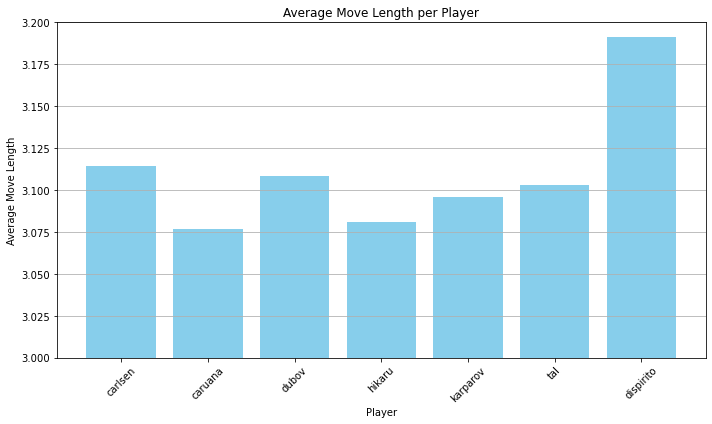

In [8]:
# plot histogram starts from 2.8 and ends at 3.2
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.ylim(3.0, 3.20)
plt.bar(tot_avg_lengths.keys(), tot_avg_lengths.values(), color='skyblue')
plt.xlabel('Player')
plt.ylabel('Average Move Length')
plt.title('Average Move Length per Player')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

There is a consistent different between normal/bad player and GM but $\mu$ is rarely over $3.4$ \
The word encoding is lightweight. (if 5 bits are used for every word).

Instead of memorizing every letter/symbol as a sequel of bit we can use the Huffman compression.

In [9]:
dic = {32: 0}

for move in every_move:
    for x in move:
        if x not in dic:
            dic[x] = 0
        dic[x] += 1
    dic[32] += 1

In [10]:
# save every_move to a file
with open('every_move.txt', 'w') as f:
    for move in every_move:
        f.write(move.decode('utf-8') + '\n')

In [12]:
# sort dic by most common
sorted_dic = sorted(dic.items(), key=lambda item: item[1], reverse=True)

print("Most common moves: \n{")
for move, count in sorted_dic:
    print(f"\t\"{chr(move)}\": {count},")
print("}\n")

Most common moves: 
{
	" ": 74059,
	"x": 15948,
	"d": 14681,
	"e": 13974,
	"5": 13610,
	"N": 13466,
	"4": 13238,
	"6": 12418,
	"R": 11999,
	"c": 11965,
	"f": 11735,
	"B": 11237,
	"3": 10695,
	"Q": 8913,
	"b": 8060,
	"g": 7991,
	"7": 7432,
	"K": 7004,
	"2": 5861,
	"a": 5644,
	"h": 5567,
	"8": 5228,
	"+": 4546,
	"1": 4145,
	"O": 3419,
	"-": 1817,
	"#": 142,
	"=": 86,
}



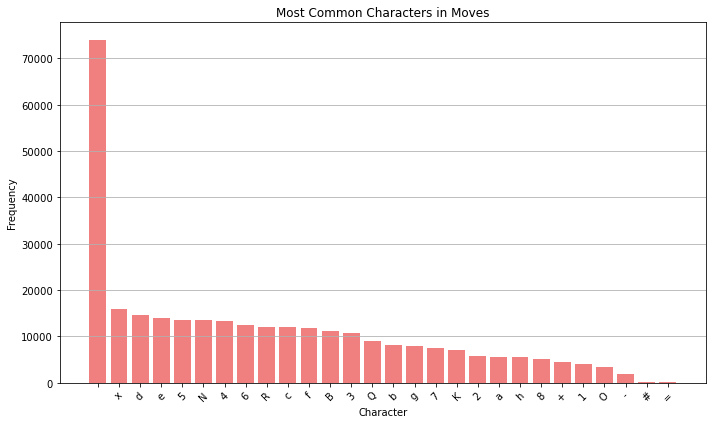

In [14]:
# diagram of most common characters
plt.figure(figsize=(10, 6))
plt.bar([chr(move[0]) for move in sorted_dic], [move[1] for move in sorted_dic], color='lightcoral')
plt.xlabel('Character')
plt.ylabel('Frequency')
plt.title('Most Common Characters in Moves')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()